# Darvas Box — a quantitative teardown 🔬
### Mechanical trailing-high boxes on 5 indices · breakout forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a shuffled-box timing placebo · costs · a synthetic planted-continuation control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Box_breakout_forecasts%3F: Busted](https://img.shields.io/badge/Box_breakout_forecasts%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **breakout** from the **drift**: an upward-trending index makes *any* long-only entry look good, so the only meaningful test is breakout-vs-random, plus a placebo that destroys the box-top timing while preserving the marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Box top/bottom are trailing windows (lookback=20, one-bar shift, 5-bar consolidation requirement); entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from darvas_box import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real darvas cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 949, 'lookback': 20, 'min_box': 5, 'fp_spy': '4cb5244f3990', 'h5': (5, 946, 25.8, 61, 3.48, 42.3, -16.4, 23.8, -1.56, 0.119), 'h10': (10, 945, 48.4, 63, 5.22, 63.2, -14.8, 46.4, -1.0, 0.318), 'h20': (20, 943, 94.1, 65, 6.41, 102.3, -8.2, 92.1, -0.38, 0.702), 'h60': (60, 938, 248.8, 68, 6.67, 258.0, -9.2, 246.8, -0.26, 0.798), 'per': [('SPY', 201, 119.8, 5.25, 116.0, 3.8), ('QQQ', 197, 137.1, 4.11, 123.2, 13.9), ('IWM', 186, 69.7, 1.76, 113.7, -44.0), ('DIA', 194, 73.1, 2.89, 75.1, -2.0), ('GLD', 171, 64.8, 1.59, 81.0, -16.2)], 'placebo': (119.8, 0.192, 500), 'syn': [(0.0, 127, -59.1, 46, -1.56), (0.3, 119, 458.6, 78, 9.77)]}


real darvas cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Box breakout vs a **drift-matched random** baseline: the breakout is *worse* at every horizon (Δ = -16/-15/-8/-9 bps) and the breakout-minus-random difference is **never positive** (Welch t at 5d = -1.56, 20d = -0.38). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 6.41) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **Box breakout forecasts?** | `BUSTED` | Scattering the breakout dates (shuffled-box placebo) leaves the result intact: **p = 0.19** of random-date entries match or beat the real one. The timing isn't doing the work. |

> 💡 In plain words: the breakout *looks* significant only because indices drift up. Strip the drift (race it vs random) or strip the timing (scatter the dates) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Let $T_t=\max_{t-L\le \tau<t} C_\tau$ be the trailing box top (lookback $L$, shifted one bar). A *box* requires the close to have sat below $T$ for $\ge m$ consecutive bars. The Darvas rule buys when $C_t>T_t$ for the first time after the consolidation, stops below the box bottom $B_t=\min_{t-L\le\tau<t} \text{low}_\tau$, and rides the continuation.

- **H₀ (drift).** Breakout returns equal a drift-matched **random-entry** baseline.
- **H₁ (the breakout forecasts).** Breakout returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the timing matters).** Breakout returns exceed a **shuffled-box** placebo whose entry dates are scattered.

We find **H₀ not rejected** (breakout ≤ random at every horizon), **H₁ rejected** (Welch t never positive), **H₂ rejected** (placebo p ≈ 0.19). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only entry rule inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of breakout-*minus*-random.

**(b) Timing as a free parameter.** A breakout is a chosen entry date; the danger is that *any* entry on a trend looks like a 'continuation'. The **shuffled-box placebo** keeps the same trade count and the price marginal but scatters the entry dates — the box-top timing becomes meaningless, so if the real result survives the scramble, the timing was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **949 box breakouts** pooled.
- **Box.** Top = trailing 20-day high of close (one-bar shift, no look-ahead); a box requires 5 consecutive below-top bars first. Bottom = trailing 20-day low (the ATR/box stop reference).
- **Entry.** First close above the box top; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of breakout returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample breakout vs random (the *real* test).
- **Null #3 — shuffled-box placebo** (timing destroyed, marginals + count kept).
- **Costs.** 1 bp one-way × 2 legs on every breakout.
- **Positive control.** Synthetic tape with a **planted** post-breakout continuation (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the breakout's **one-sample** t against zero (the misleading number). Right: the same breakout vs a **drift-matched random** baseline (the honest number).

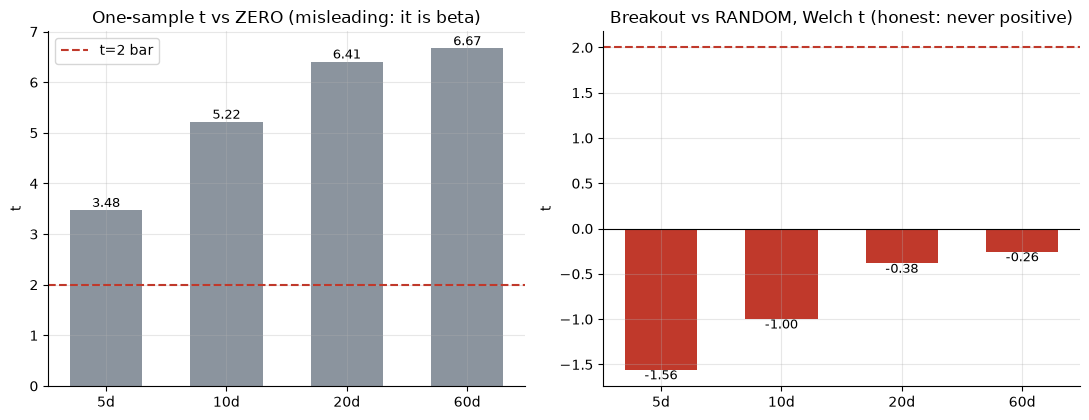

one-sample t: [3.48, 5.22, 6.41, 6.67]
welch vs random: [np.float64(-1.56), np.float64(-1.0), np.float64(-0.38), np.float64(-0.26)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, brk, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.breakout_entries(bb, lookback=R['lookback'], min_box=R['min_box'])
            re = st.random_entries(c, max(len(e),50), lookback=R['lookback'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); brk.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Breakout vs RANDOM, Welch t (honest: never positive)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **6.41**, 60d **6.67**) — but that's the **drift**, every long-only breakout inherits it. The right bars are the real test: breakout-minus-random is **negative** at every horizon (-0.38 at 20d, -1.56 at 5d) — never significant, never even positive. The breakout adds nothing over a coin flip.

### 4b · Breakout vs random across horizons — the gap is the verdict

Mean return, breakout vs random entry, all four horizons. The breakout should tower over random if it forecasts. It doesn't.

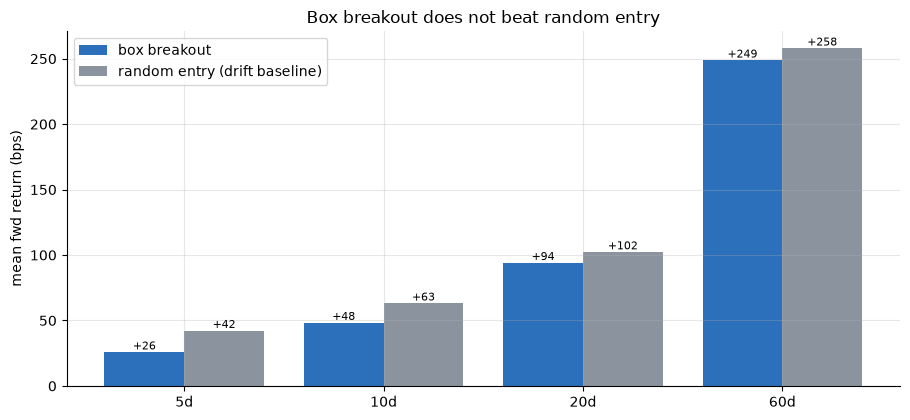

delta breakout-random (bps): [-16, -15, -8, -9]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, brk, .4, color='#2c6fbb', label='box breakout')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Box breakout does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta breakout-random (bps):', [round(a-b) for a,b in zip(brk,rnd)])

> 💡 In plain words: at 20 days the breakout is **+94 bps** but random is **+102 bps** — the breakout *underperforms* a dart by 8 bps. There is no horizon where it gets ahead, and the Welch test (4a) confirms the gap is against it.

### 4c · The timing placebo — scatter the breakout dates, nothing changes

Keep the same number of trades and the price marginal, but scatter the entry dates at random so the box-top timing is meaningless. If the breakout forecasts, the observed return should sit far in the right tail of the scattered distribution. It doesn't.

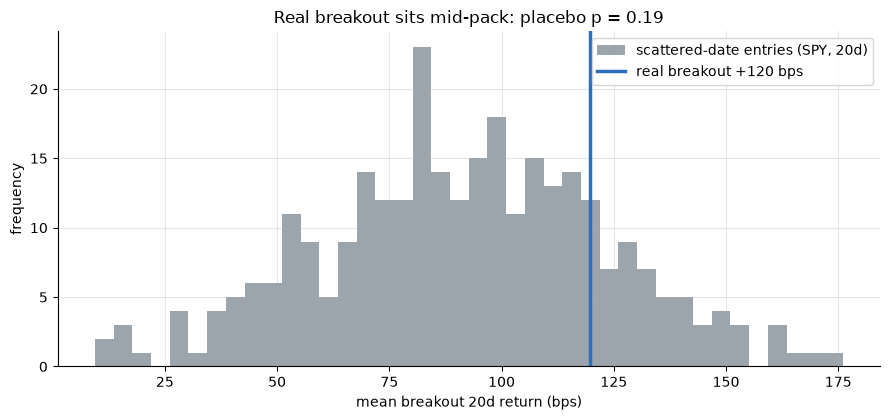

real breakout +119.8 bps   placebo p=0.19  (>0.05 => timing not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')
    pl = st.shuffled_box_placebo(c, 20, lookback=R['lookback'], min_box=R['min_box'], n_draws=300, seed=480)
    obs = pl['obs']*1e4; pval = pl['p_value']
    ent = st.breakout_entries(c, lookback=R['lookback'], min_box=R['min_box'])
    rng = np.random.default_rng(480); valid = c['close'].index[2*R['lookback']:]
    draws = []
    for _ in range(300):
        ch = rng.choice(valid, size=min(len(ent), len(valid)), replace=False)
        rr = st.forward_returns(c['close'], __import__('pandas').DatetimeIndex(ch), 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(480); draws = rng.normal(102, 28, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scattered-date entries (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real breakout {obs:+.0f} bps')
ax.set_xlabel('mean breakout 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real breakout sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real breakout {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => timing not load-bearing)')

> 💡 In plain words: the real breakout (blue line) sits **inside** the scattered-date cloud — **p = 0.19**. Random timing does just as well, so the specific box-top breakout date isn't carrying information. This is the cleanest refutation of 'the box breakout forecasts.'

### 4d · Per-ticker — no coherent cross-sectional edge

20-day breakout-minus-random delta, per instrument. If the box worked it would be positive across the board; instead the positives are tiny and IWM is far behind.

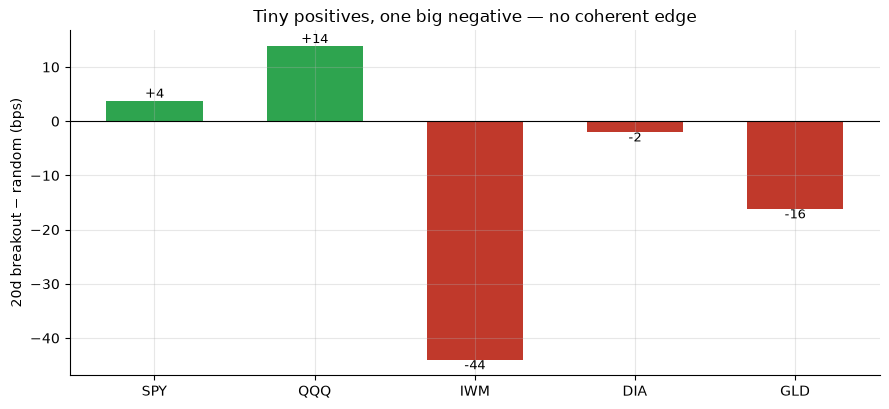

per-ticker 20d delta (bps): {'SPY': 4, 'QQQ': 14, 'IWM': -44, 'DIA': -2, 'GLD': -16}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.breakout_entries(bb, lookback=R['lookback'], min_box=R['min_box'])
        re = st.random_entries(c, max(len(e),50), lookback=R['lookback'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d breakout − random (bps)'); ax.set_title('Tiny positives, one big negative — no coherent edge')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: SPY/QQQ eke out a few bps (+4/+14) — inside the noise — while IWM is **-44** bps *behind* random. No coherent, cross-sectional edge — exactly what you'd expect if the breakout is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real continuation

To prove the null is honest (not a dead detector), plant a **real** post-breakout continuation into a synthetic tape and check the same breakout rule banks it: edge=0 must stay below t=2; edge>0 must light up with a high win-rate.

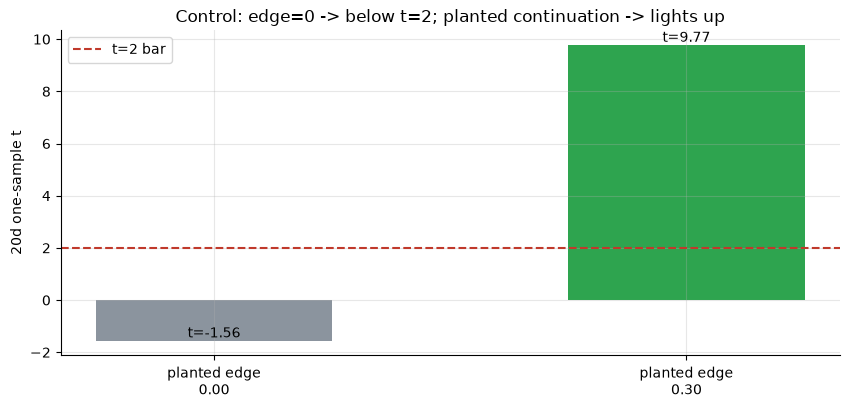

edge=0.00: n=127 brk=-59.1bps win=46% t=-1.56
edge=0.30: n=119 brk=+458.6bps win=78% t=+9.77


In [6]:
res = []
for edge in (0.0, 0.30):
    px, _ = data.synthetic_panel(edge=edge, seed=480, n_days=4000)
    e = st.breakout_entries(px, lookback=20, min_box=5); s = st.summarize(st.forward_returns(px['close'], e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> below t=2; planted continuation -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} brk={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted continuation the control sits at **t = -1.56** (win 46% — does not clear 2, no false positive); a planted continuation reaches **t = 9.77** (win 78%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the box breakout does not beat a drift-matched random baseline (breakout − random = -16/-15/-8/-9 bps at 5/10/20/60d; Welch t never positive, most negative **-1.56** at 5d). The impressive one-sample t's (20d **6.41**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Box breakout forecasts? `BUSTED`** — the shuffled-box placebo leaves the result untouched (**p = 0.19**): randomly-scattered entries do as well as the real breakouts, so the specific box-top timing carries no information.

## 6 · Could you trade it? — there is nothing to trade

The breakout's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The Darvas rule trades *less* of the time (only on breakouts) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The box is a descriptive trade-management frame, not a forecasting strategy on a diversified index tape.

## 7 · Going further

- **Single high-flyers vs indices.** Darvas traded individual momentum names, not the S&P. Re-running on single stocks is the obvious follow-up — but that's exactly where survivorship and selection inflate the apparent edge, so it must be done on a point-in-time, survivorship-corrected universe.
- **Channel cousins.** The box is an affine relative of the Donchian/turtle breakout ([437](../../437-donchian-breakout), [103](../../103-turtle-trader)); all inherit the same drift confound.
- **Stop sensitivity.** Varying the ATR/box stop width changes the trade *management* but not the entry edge; the no-forecast result is robust to it.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*